# Research Question 4: Category Concentration by Quartier in 2025

## Research Question

Are certain types of ZüriWieNeu reports concentrated in particular Zurich Quartiere in 2025?

## Goal of this notebook

The goal of this notebook is to analyse whether specific categories of ZüriWieNeu reports are spatially concentrated in certain Zurich Quartiere in 2025.

While Research Question 3 examined the total number of reports per Quartier, this notebook focuses on the types of reports. This makes it possible to investigate whether some neighbourhoods are especially associated with certain kinds of urban issues, such as waste, street infrastructure, lighting, green spaces, or traffic signals.

## Why this question is relevant

Different Quartiere may have different urban functions and land-use patterns. For example, central or nightlife-oriented areas may show different reporting patterns than residential or peripheral areas. Analysing report categories at the Quartier level can therefore provide a more detailed understanding of urban reporting patterns in Zurich.

However, category concentrations should be interpreted carefully. A high number of reports in a category may reflect actual local issues, but it may also be influenced by population density, visitor activity, infrastructure density, or differences in reporting behaviour.

## Planned analysis

In this notebook, I will:

1. Load and clean the ZüriWieNeu report data.
2. Filter the reports to the year 2025.
3. Convert report coordinates into a GeoDataFrame.
4. Spatially join reports to Zurich Quartiere.
5. Count reports by Quartier and category.
6. Identify the dominant report category in each Quartier.
7. Visualize the dominant categories on a map.
8. Interpret whether specific report types appear spatially concentrated.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from src.loading import load_csv_data
from src.cleaning import clean_reports
from src.spatial import reports_to_geodataframe, join_reports_to_quartiere

In [5]:
df_raw = load_csv_data("/Users/laumagoldmann/Desktop/SDS210_IndividualProject/data/raw/stzh.zwn_meldungen_p.csv")
df_clean = clean_reports(df_raw)

df_2025 = df_clean[df_clean["year"] == 2025].copy()

quartiere = gpd.read_file(
    "/Users/laumagoldmann/Desktop/SDS210_IndividualProject/data/raw/StatQuartiere_ZH"
)

reports_2025_gdf = reports_to_geodataframe(df_2025)

reports_2025_joined = join_reports_to_quartiere(
    reports_2025_gdf,
    quartiere
)

reports_2025_joined[["service_request_id", "qname", "service_name"]].head()

/Users/laumagoldmann/miniconda3/envs/sds-env/lib/python3.14/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'StatQuartiere_ZH': 'stzh.adm_statistische_quartiere_v' (default), 'stzh.adm_statistische_quartiere_b_p', 'stzh.adm_statistische_quartiere_map'. Specify layer parameter to avoid this warning.
  result = read_func(


,service_request_id,qname,service_name
44670,70201,Langstrasse,Abfall/Sammelstelle
45845,68672,Hard,Abfall/Sammelstelle
45867,69139,City,Beleuchtung/Uhren
45975,70728,Sihlfeld,Abfall/Sammelstelle
46705,65900,Hochschulen,Graffiti


In [8]:
quartier_category_counts = (
    reports_2025_joined
    .groupby(["qname", "service_name"])
    .size()
    .reset_index(name="report_count")
    .sort_values("report_count", ascending=False)
)

quartier_category_counts.head(10)

,qname,service_name,report_count
157,Langstrasse,Abfall/Sammelstelle,824
265,Sihlfeld,Abfall/Sammelstelle,477
99,Hard,Abfall/Sammelstelle,274
20,Alt-Wiedikon,Abfall/Sammelstelle,259
30,Altstetten,Abfall/Sammelstelle,244
245,Seebach,Abfall/Sammelstelle,220
275,Unterstrass,Abfall/Sammelstelle,191
294,Werd,Abfall/Sammelstelle,178
303,Wipkingen,Abfall/Sammelstelle,159
0,Affoltern,Abfall/Sammelstelle,129


In [9]:
quartier_totals = (
    reports_2025_joined
    .groupby("qname")
    .size()
    .reset_index(name="total_reports")
)

quartier_category_shares = quartier_category_counts.merge(
    quartier_totals,
    on="qname",
    how="left"
)

quartier_category_shares["category_share"] = (
    quartier_category_shares["report_count"]
    / quartier_category_shares["total_reports"]
    * 100
)

quartier_category_shares.sort_values(
    "category_share",
    ascending=False
).head(10)

,qname,service_name,report_count,total_reports,category_share
0,Langstrasse,Abfall/Sammelstelle,824,1200,68.666667
7,Werd,Abfall/Sammelstelle,178,267,66.666667
1,Sihlfeld,Abfall/Sammelstelle,477,795,60.000000
2,Hard,Abfall/Sammelstelle,274,470,58.297872
3,Alt-Wiedikon,Abfall/Sammelstelle,259,456,56.798246
15,Seefeld,Abfall/Sammelstelle,119,221,53.846154
34,Weinegg,Abfall/Sammelstelle,62,123,50.406504
5,Seebach,Abfall/Sammelstelle,220,464,47.413793
32,Mühlebach,Abfall/Sammelstelle,66,160,41.250000
9,Affoltern,Abfall/Sammelstelle,129,331,38.972810


## Category shares within Quartiere

The table above shows the categories with the highest local shares within each Quartier in 2025.

The results show that **Abfall/Sammelstelle** dominates many of the strongest Quartier-category combinations. In Langstrasse, for example, this category accounts for almost 69% of all reports. Similar patterns are visible in Werd, Sihlfeld, Hard, and Alt-Wiedikon.

This suggests that waste and collection-point issues are not only frequent across the city overall, but are especially concentrated in certain Quartiere. However, these results should be interpreted as reporting patterns rather than direct measurements of urban cleanliness or infrastructure quality.
``

In [10]:
dominant_category_by_quartier = (
    quartier_category_shares
    .sort_values(["qname", "category_share"], ascending=[True, False])
    .groupby("qname")
    .first()
    .reset_index()
)

dominant_category_by_quartier.head(10)

,qname,service_name,report_count,total_reports,category_share
0,Affoltern,Abfall/Sammelstelle,129,331,38.972810
1,Albisrieden,Abfall/Sammelstelle,122,360,33.888889
2,Alt-Wiedikon,Abfall/Sammelstelle,259,456,56.798246
3,Altstetten,Abfall/Sammelstelle,244,628,38.853503
4,City,Abfall/Sammelstelle,75,288,26.041667
5,Enge,Abfall/Sammelstelle,97,360,26.944444
6,Escher Wyss,Abfall/Sammelstelle,40,212,18.867925
7,Fluntern,Abfall/Sammelstelle,62,218,28.440367
8,Friesenberg,Abfall/Sammelstelle,54,198,27.272727
9,Gewerbeschule,Abfall/Sammelstelle,123,353,34.844193


In [11]:
dominant_category_by_quartier["service_name"].value_counts()

service_name
Abfall/Sammelstelle          32
Signalisation/Lichtsignal     2
Name: count, dtype: int64

In [12]:
abfall_share = quartier_category_shares[
    quartier_category_shares["service_name"] == "Abfall/Sammelstelle"
].copy()

abfall_share = abfall_share.sort_values(
    "category_share",
    ascending=False
)

abfall_share.head(10)

,qname,service_name,report_count,total_reports,category_share
0,Langstrasse,Abfall/Sammelstelle,824,1200,68.666667
7,Werd,Abfall/Sammelstelle,178,267,66.666667
1,Sihlfeld,Abfall/Sammelstelle,477,795,60.000000
2,Hard,Abfall/Sammelstelle,274,470,58.297872
3,Alt-Wiedikon,Abfall/Sammelstelle,259,456,56.798246
15,Seefeld,Abfall/Sammelstelle,119,221,53.846154
34,Weinegg,Abfall/Sammelstelle,62,123,50.406504
5,Seebach,Abfall/Sammelstelle,220,464,47.413793
32,Mühlebach,Abfall/Sammelstelle,66,160,41.250000
9,Affoltern,Abfall/Sammelstelle,129,331,38.972810


In [13]:
quartiere_abfall_share = quartiere.merge(
    abfall_share[["qname", "category_share", "report_count", "total_reports"]],
    on="qname",
    how="left"
)

quartiere_abfall_share[["qname", "category_share", "report_count", "total_reports"]].sort_values(
    "category_share",
    ascending=False
).head(10)

,qname,category_share,report_count,total_reports
2,Langstrasse,68.666667,824,1200
27,Werd,66.666667,178,267
17,Sihlfeld,60.000000,477,795
29,Hard,58.297872,274,470
0,Alt-Wiedikon,56.798246,259,456
6,Seefeld,53.846154,119,221
5,Weinegg,50.406504,62,123
32,Seebach,47.413793,220,464
9,Mühlebach,41.250000,66,160
18,Affoltern,38.972810,129,331


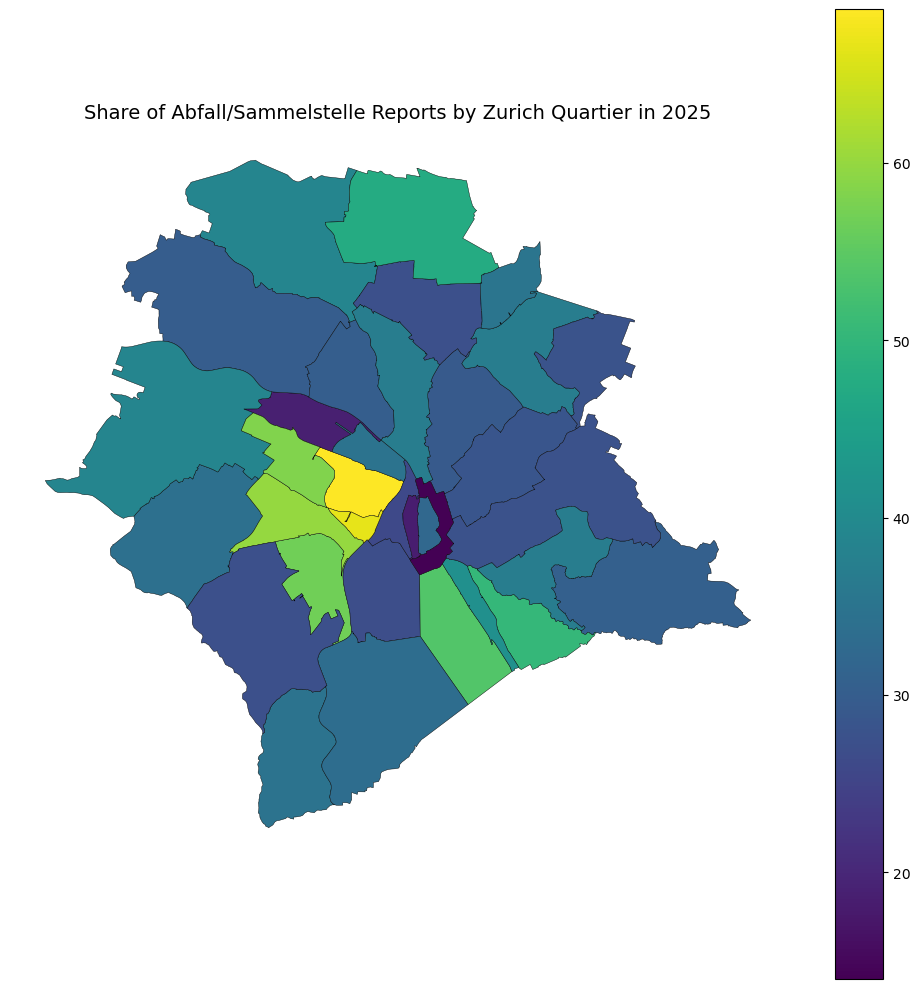

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

quartiere_abfall_share.plot(
    column="category_share",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title(
    "Share of Abfall/Sammelstelle Reports by Zurich Quartier in 2025",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.show()

## Interpretation of the Abfall/Sammelstelle share map

The choropleth map shows the share of **Abfall/Sammelstelle** reports within each Zurich Quartier in 2025.

This relative measure is useful because it does not only show where many waste-related reports occurred, but where waste-related reports made up a particularly large proportion of all local reports.

The map shows that **Abfall/Sammelstelle** reports are especially concentrated in Quartiere such as **Langstrasse**, **Werd**, **Sihlfeld**, **Hard**, and **Alt-Wiedikon**. In Langstrasse, for example, almost 69% of all ZüriWieNeu reports in 2025 belonged to this category.

This suggests that waste and collection-point issues were particularly important in these Quartiere compared with other types of reported problems. However, the results should be interpreted as reporting patterns rather than direct measurements of cleanliness or infrastructure quality. High shares may also be influenced by population density, nightlife, visitor activity, commercial land use, or differences in residents' reporting behaviour.

## Conclusion

This notebook analysed whether certain types of ZüriWieNeu reports were concentrated in particular Zurich Quartiere in 2025.

The first analysis of Quartier-category combinations showed that **Abfall/Sammelstelle** dominated the strongest absolute concentrations. The largest combination was **Langstrasse – Abfall/Sammelstelle**, with 824 reports.

The analysis of dominant categories showed that **Abfall/Sammelstelle** was the most common category in 32 out of 34 Quartiere. This indicates that waste and collection-point issues were not only frequent citywide, but also locally dominant in most neighbourhoods.

To better understand spatial concentration, the analysis then focused on the share of **Abfall/Sammelstelle** reports within each Quartier. This revealed that the category was especially concentrated in Quartiere such as **Langstrasse**, **Werd**, **Sihlfeld**, **Hard**, and **Alt-Wiedikon**.

Overall, the results show that category patterns in 2025 were strongly shaped by waste-related reports. While this may point to specific urban management challenges, the findings should be interpreted carefully because ZüriWieNeu data reflects reported issues, not necessarily the full distribution of actual infrastructure problems.